In [2]:
#%pip install pandas_datareader

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
import datetime

pd.options.mode.copy_on_write = True

In [9]:
import warnings
warnings.filterwarnings("always")

In [66]:
spy_adj_close = yf.download(["SPY","USDSGD=X"], start="2023-01-01", end="2024-10-24")[["Adj Close"]]
spy_adj_close.index = spy_adj_close.index.date
spy_adj_close.dropna(inplace=True)
spy_adj_close.reset_index(inplace=True)
spy_adj_close.columns = ['Date', 'AdjCloseUSD', 'FxRate']
spy_adj_close

[*********************100%***********************]  2 of 2 completed


,Date,AdjCloseUSD,FxRate
0,2023-01-03,371.614410,1.34120
1,2023-01-04,374.483368,1.34534
2,2023-01-05,370.209229,1.34144
3,2023-01-06,378.698914,1.34552
4,2023-01-09,378.484253,1.33379
...,...,...,...
449,2024-10-17,582.349976,1.31335
450,2024-10-18,584.590027,1.31417
451,2024-10-21,583.630005,1.30998
452,2024-10-22,583.320007,1.31665


In [67]:
# if we want no fx conversion, set this to 1
spy_adj_close['FxRate'] = 1
spy_adj_close

,Date,AdjCloseUSD,FxRate
0,2023-01-03,371.614410,1
1,2023-01-04,374.483368,1
2,2023-01-05,370.209229,1
3,2023-01-06,378.698914,1
4,2023-01-09,378.484253,1
...,...,...,...
449,2024-10-17,582.349976,1
450,2024-10-18,584.590027,1
451,2024-10-21,583.630005,1
452,2024-10-22,583.320007,1


In [68]:
unit_price_start_sgd = spy_adj_close.loc[0, 'AdjCloseUSD'] * spy_adj_close.loc[0, 'FxRate']
unit_price_now_sgd = spy_adj_close.loc[len(spy_adj_close)-1, 'AdjCloseUSD'] * spy_adj_close.loc[len(spy_adj_close)-1, 'FxRate']
pnl_pct = (unit_price_now_sgd - unit_price_start_sgd) / unit_price_start_sgd * 100

print(unit_price_start_sgd)
print(unit_price_now_sgd)
print(pnl_pct)

371.6144104003906
577.989990234375
55.534870031446836


In [15]:
spy_df = spy_adj_close.copy()

sip_amount_sgd = 100
fees = 1.0
period = 1

spy_df['ClosePctChg'] = spy_df['AdjCloseUSD'].pct_change().fillna(0)
spy_df

,Date,AdjCloseUSD,FxRate,ClosePctChg
0,2023-01-03,371.614441,1,0.000000
1,2023-01-04,374.483368,1,0.007720
2,2023-01-05,370.209198,1,-0.011414
3,2023-01-06,378.698914,1,0.022932
4,2023-01-09,378.484253,1,-0.000567
...,...,...,...,...
449,2024-10-17,582.349976,1,0.000086
450,2024-10-18,584.590027,1,0.003847
451,2024-10-21,583.630005,1,-0.001642
452,2024-10-22,583.320007,1,-0.000531


In [16]:
spy_df['SipAmountUSD'] = spy_df.apply(lambda row: 0 if row.name % period != 0 else sip_amount_sgd/row['FxRate'], axis=1)
spy_df

,Date,AdjCloseUSD,FxRate,ClosePctChg,SipAmountUSD
0,2023-01-03,371.614441,1,0.000000,100.0
1,2023-01-04,374.483368,1,0.007720,100.0
2,2023-01-05,370.209198,1,-0.011414,100.0
3,2023-01-06,378.698914,1,0.022932,100.0
4,2023-01-09,378.484253,1,-0.000567,100.0
...,...,...,...,...,...
449,2024-10-17,582.349976,1,0.000086,100.0
450,2024-10-18,584.590027,1,0.003847,100.0
451,2024-10-21,583.630005,1,-0.001642,100.0
452,2024-10-22,583.320007,1,-0.000531,100.0


In [17]:
spy_df['DailyUnit'] = (spy_df['SipAmountUSD'] - fees) / spy_df['AdjCloseUSD']
spy_df

,Date,AdjCloseUSD,FxRate,ClosePctChg,SipAmountUSD,DailyUnit
0,2023-01-03,371.614441,1,0.000000,100.0,0.266405
1,2023-01-04,374.483368,1,0.007720,100.0,0.264364
2,2023-01-05,370.209198,1,-0.011414,100.0,0.267416
3,2023-01-06,378.698914,1,0.022932,100.0,0.261421
4,2023-01-09,378.484253,1,-0.000567,100.0,0.261570
...,...,...,...,...,...,...
449,2024-10-17,582.349976,1,0.000086,100.0,0.170001
450,2024-10-18,584.590027,1,0.003847,100.0,0.169349
451,2024-10-21,583.630005,1,-0.001642,100.0,0.169628
452,2024-10-22,583.320007,1,-0.000531,100.0,0.169718


In [18]:
spy_df['CumUnit'] = spy_df['DailyUnit'].cumsum()
spy_df

,Date,AdjCloseUSD,FxRate,ClosePctChg,SipAmountUSD,DailyUnit,CumUnit
0,2023-01-03,371.614441,1,0.000000,100.0,0.266405,0.266405
1,2023-01-04,374.483368,1,0.007720,100.0,0.264364,0.530769
2,2023-01-05,370.209198,1,-0.011414,100.0,0.267416,0.798186
3,2023-01-06,378.698914,1,0.022932,100.0,0.261421,1.059607
4,2023-01-09,378.484253,1,-0.000567,100.0,0.261570,1.321177
...,...,...,...,...,...,...,...
449,2024-10-17,582.349976,1,0.000086,100.0,0.170001,96.968369
450,2024-10-18,584.590027,1,0.003847,100.0,0.169349,97.137719
451,2024-10-21,583.630005,1,-0.001642,100.0,0.169628,97.307347
452,2024-10-22,583.320007,1,-0.000531,100.0,0.169718,97.477065


In [19]:
spy_df['PortValueSGD'] = spy_df['CumUnit'] * spy_df['AdjCloseUSD'] * spy_df['FxRate']
spy_df

,Date,AdjCloseUSD,FxRate,ClosePctChg,SipAmountUSD,DailyUnit,CumUnit,PortValueSGD
0,2023-01-03,371.614441,1,0.000000,100.0,0.266405,0.266405,99.000000
1,2023-01-04,374.483368,1,0.007720,100.0,0.264364,0.530769,198.764297
2,2023-01-05,370.209198,1,-0.011414,100.0,0.267416,0.798186,295.495698
3,2023-01-06,378.698914,1,0.022932,100.0,0.261421,1.059607,401.272068
4,2023-01-09,378.484253,1,-0.000567,100.0,0.261570,1.321177,500.044612
...,...,...,...,...,...,...,...,...
449,2024-10-17,582.349976,1,0.000086,100.0,0.170001,96.968369,56469.527432
450,2024-10-18,584.590027,1,0.003847,100.0,0.169349,97.137719,56785.741551
451,2024-10-21,583.630005,1,-0.001642,100.0,0.169628,97.307347,56791.487207
452,2024-10-22,583.320007,1,-0.000531,100.0,0.169718,97.477065,56860.322167


In [22]:
spy_df['CumSipAmtSGD'] = spy_df['SipAmountUSD'].cumsum() * spy_df['FxRate']
spy_df

,Date,AdjCloseUSD,FxRate,ClosePctChg,SipAmountUSD,DailyUnit,CumUnit,PortValueSGD,CumSipAmtSGD
0,2023-01-03,371.614441,1,0.000000,100.0,0.266405,0.266405,99.000000,100.0
1,2023-01-04,374.483368,1,0.007720,100.0,0.264364,0.530769,198.764297,200.0
2,2023-01-05,370.209198,1,-0.011414,100.0,0.267416,0.798186,295.495698,300.0
3,2023-01-06,378.698914,1,0.022932,100.0,0.261421,1.059607,401.272068,400.0
4,2023-01-09,378.484253,1,-0.000567,100.0,0.261570,1.321177,500.044612,500.0
...,...,...,...,...,...,...,...,...,...
449,2024-10-17,582.349976,1,0.000086,100.0,0.170001,96.968369,56469.527432,45000.0
450,2024-10-18,584.590027,1,0.003847,100.0,0.169349,97.137719,56785.741551,45100.0
451,2024-10-21,583.630005,1,-0.001642,100.0,0.169628,97.307347,56791.487207,45200.0
452,2024-10-22,583.320007,1,-0.000531,100.0,0.169718,97.477065,56860.322167,45300.0


In [25]:
spy_df['CumPnLSGD'] = spy_df['PortValueSGD'] - spy_df['CumSipAmtSGD']
spy_df

,Date,AdjCloseUSD,FxRate,ClosePctChg,SipAmountUSD,DailyUnit,CumUnit,PortValueSGD,CumSipAmtSGD,CumPnLSGD
0,2023-01-03,371.614441,1,0.000000,100.0,0.266405,0.266405,99.000000,100.0,-1.000000
1,2023-01-04,374.483368,1,0.007720,100.0,0.264364,0.530769,198.764297,200.0,-1.235703
2,2023-01-05,370.209198,1,-0.011414,100.0,0.267416,0.798186,295.495698,300.0,-4.504302
3,2023-01-06,378.698914,1,0.022932,100.0,0.261421,1.059607,401.272068,400.0,1.272068
4,2023-01-09,378.484253,1,-0.000567,100.0,0.261570,1.321177,500.044612,500.0,0.044612
...,...,...,...,...,...,...,...,...,...,...
449,2024-10-17,582.349976,1,0.000086,100.0,0.170001,96.968369,56469.527432,45000.0,11469.527432
450,2024-10-18,584.590027,1,0.003847,100.0,0.169349,97.137719,56785.741551,45100.0,11685.741551
451,2024-10-21,583.630005,1,-0.001642,100.0,0.169628,97.307347,56791.487207,45200.0,11591.487207
452,2024-10-22,583.320007,1,-0.000531,100.0,0.169718,97.477065,56860.322167,45300.0,11560.322167


In [26]:
spy_df['CumPnLPct'] = (spy_df['CumPnLSGD'] / spy_df['CumSipAmtSGD']) * 100
spy_df

,Date,AdjCloseUSD,FxRate,ClosePctChg,SipAmountUSD,DailyUnit,CumUnit,PortValueSGD,CumSipAmtSGD,CumPnLSGD,CumPnLPct
0,2023-01-03,371.614441,1,0.000000,100.0,0.266405,0.266405,99.000000,100.0,-1.000000,-1.000000
1,2023-01-04,374.483368,1,0.007720,100.0,0.264364,0.530769,198.764297,200.0,-1.235703,-0.617852
2,2023-01-05,370.209198,1,-0.011414,100.0,0.267416,0.798186,295.495698,300.0,-4.504302,-1.501434
3,2023-01-06,378.698914,1,0.022932,100.0,0.261421,1.059607,401.272068,400.0,1.272068,0.318017
4,2023-01-09,378.484253,1,-0.000567,100.0,0.261570,1.321177,500.044612,500.0,0.044612,0.008922
...,...,...,...,...,...,...,...,...,...,...,...
449,2024-10-17,582.349976,1,0.000086,100.0,0.170001,96.968369,56469.527432,45000.0,11469.527432,25.487839
450,2024-10-18,584.590027,1,0.003847,100.0,0.169349,97.137719,56785.741551,45100.0,11685.741551,25.910735
451,2024-10-21,583.630005,1,-0.001642,100.0,0.169628,97.307347,56791.487207,45200.0,11591.487207,25.644883
452,2024-10-22,583.320007,1,-0.000531,100.0,0.169718,97.477065,56860.322167,45300.0,11560.322167,25.519475


In [28]:
spy_df['Days'] = spy_df['Date'].diff()
spy_df.loc[0, 'Days'] = pd.to_timedelta(0)
spy_df

,Date,AdjCloseUSD,FxRate,ClosePctChg,SipAmountUSD,DailyUnit,CumUnit,PortValueSGD,CumSipAmtSGD,CumPnLSGD,CumPnLPct,Days
0,2023-01-03,371.614441,1,0.000000,100.0,0.266405,0.266405,99.000000,100.0,-1.000000,-1.000000,0 days
1,2023-01-04,374.483368,1,0.007720,100.0,0.264364,0.530769,198.764297,200.0,-1.235703,-0.617852,1 days
2,2023-01-05,370.209198,1,-0.011414,100.0,0.267416,0.798186,295.495698,300.0,-4.504302,-1.501434,1 days
3,2023-01-06,378.698914,1,0.022932,100.0,0.261421,1.059607,401.272068,400.0,1.272068,0.318017,1 days
4,2023-01-09,378.484253,1,-0.000567,100.0,0.261570,1.321177,500.044612,500.0,0.044612,0.008922,3 days
...,...,...,...,...,...,...,...,...,...,...,...,...
449,2024-10-17,582.349976,1,0.000086,100.0,0.170001,96.968369,56469.527432,45000.0,11469.527432,25.487839,1 days
450,2024-10-18,584.590027,1,0.003847,100.0,0.169349,97.137719,56785.741551,45100.0,11685.741551,25.910735,1 days
451,2024-10-21,583.630005,1,-0.001642,100.0,0.169628,97.307347,56791.487207,45200.0,11591.487207,25.644883,3 days
452,2024-10-22,583.320007,1,-0.000531,100.0,0.169718,97.477065,56860.322167,45300.0,11560.322167,25.519475,1 days


,Date,AdjCloseUSD,FxRate,ClosePctChg,SipAmountUSD,DailyUnit,CumUnit,PortValueSGD,CumSipAmtSGD,CumPnLSGD,CumPnLPct,Days,CumSipCompSGD
0,2023-01-03,371.614441,1,0.000000,100.0,0.266405,0.266405,99.000000,100.0,-1.000000,-1.000000,0 days,100.000000
1,2023-01-04,374.483368,1,0.007720,100.0,0.264364,0.530769,198.764297,200.0,-1.235703,-0.617852,1 days,200.067656
2,2023-01-05,370.209198,1,-0.011414,100.0,0.267416,0.798186,295.495698,300.0,-4.504302,-1.501434,1 days,300.203013
3,2023-01-06,378.698914,1,0.022932,100.0,0.261421,1.059607,401.272068,400.0,1.272068,0.318017,1 days,400.406118
4,2023-01-09,378.484253,1,-0.000567,100.0,0.261570,1.321177,500.044612,500.0,0.044612,0.008922,3 days,501.219361
...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,2024-10-17,582.349976,1,0.000086,100.0,0.170001,96.968369,56469.527432,45000.0,11469.527432,25.487839,1 days,56591.711233
450,2024-10-18,584.590027,1,0.003847,100.0,0.169349,97.137719,56785.741551,45100.0,11685.741551,25.910735,1 days,56729.998793
451,2024-10-21,583.630005,1,-0.001642,100.0,0.169628,97.307347,56791.487207,45200.0,11591.487207,25.644883,3 days,56945.220072
452,2024-10-22,583.320007,1,-0.000531,100.0,0.169718,97.477065,56860.322167,45300.0,11560.322167,25.519475,1 days,57083.746801


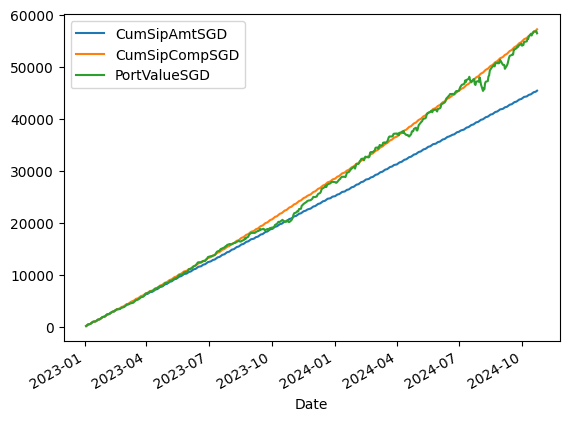

In [ ]:
#CAGR estimation
cagr = 28 / 100
for index, row in spy_df.iterrows():
    if index == 0:
        prev_cum_sip_comp_sgd = 0
    else:
        prev_cum_sip_comp_sgd = spy_df.at[index-1, 'CumSipCompSGD']
    sip_amount_today_sgd = row['SipAmountUSD'] * row['FxRate']
    years = row['Days'].days / 365
    spy_df.at[index, 'CumSipCompSGD'] = prev_cum_sip_comp_sgd * (1 + cagr) ** years + sip_amount_today_sgd

spy_df.plot(x='Date', y=['CumSipAmtSGD', 'CumSipCompSGD', 'PortValueSGD'])

#spy_df[spy_df["SipAmountUSD"] != 0]
spy_df

In [22]:
maxCumPnLPct = spy_df['CumPnLPct'].max()
maxCumPnLPct

11.689189417831122

In [23]:
spy_df[['Date', 'CumPnLPct']].query('CumPnLPct < 0.2 & CumPnLPct > 0')

,Date,CumPnLPct
74,2024-04-18,0.040547
76,2024-04-22,0.089167
83,2024-05-01,0.116407


<Axes: >

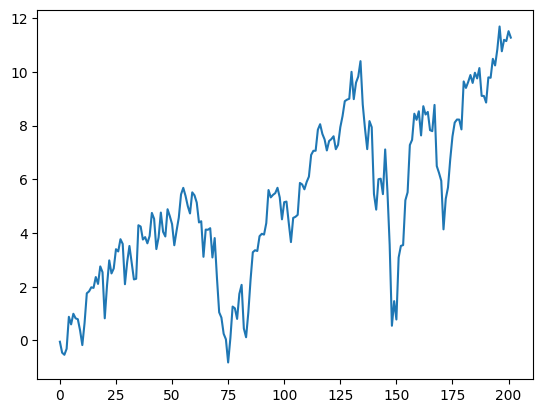

In [24]:
spy_df['CumPnLPct'].plot()